# Lab 6: Actor-Critic on LunarLanderContinuous-v3

## Design Constraints

- A trained Agent must be saveable and restorable from disk (weights + config) so visualizations can be reproduced in the notebook without retraining.
- All hyperparameter choices (learning rates, architecture, activation functions, initial log-std, entropy regularization) must be documented in the notebook.

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import glob, os

for f in glob.glob("../data/*.*") + glob.glob("../img/*.*"):
    os.remove(f)
    print(f"removed {f}")

In [3]:
# Project Structure
# DONE: Establish /src, /test, /data, /img directory layout

! tree ..

..
├── data
│   └── test_runs
├── img
├── ipynb
│   ├── development.ipynb
│   ├── report.html
│   └── report.ipynb
├── README.md
├── src
│   ├── __init__.py
│   ├── __pycache__
│   │   ├── __init__.cpython-311.pyc
│   │   ├── agent.cpython-311.pyc
│   │   ├── ensemble.cpython-311.pyc
│   │   └── trainer.cpython-311.pyc
│   ├── agent.py
│   ├── ensemble.py
│   └── trainer.py
└── test
    ├── __pycache__
    │   ├── conftest.cpython-311-pytest-9.0.2.pyc
    │   ├── test_actor.cpython-311-pytest-9.0.2.pyc
    │   ├── test_agent.cpython-311-pytest-9.0.2.pyc
    │   ├── test_critic.cpython-311-pytest-9.0.2.pyc
    │   ├── test_ensemble.cpython-311-pytest-9.0.2.pyc
    │   └── test_trainer.cpython-311-pytest-9.0.2.pyc
    ├── conftest.py
    ├── test_actor.py
    ├── test_agent.py
    ├── test_critic.py
    ├── test_ensemble.py
    └── test_trainer.py

9 directories, 24 files


In [4]:
# DONE: Verify PyTorch and Gymnasium are available; instantiate LunarLanderContinuous-v2
#       and inspect observation space, action space shape, and action bounds
import torch
import gymnasium as gym

print(f"PyTorch  : {torch.__version__}")
print(f"Gymnasium: {gym.__version__}")

env = gym.make("LunarLanderContinuous-v3")
obs_space = env.observation_space
act_space = env.action_space

print(f"\nObservation space : {obs_space}")
print(f"Action space      : {act_space}")
print(f"Action shape      : {act_space.shape}")
print(f"Action low        : {act_space.low}")
print(f"Action high       : {act_space.high}")
env.close()

PyTorch  : 2.10.0
Gymnasium: 1.2.3

Observation space : Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space      : Box(-1.0, 1.0, (2,), float32)
Action shape      : (2,)
Action low        : [-1. -1.]
Action high       : [1. 1.]


### Actor Hyperparameters

| Parameter | Value | Notes |
|---|---|---|
| `obs_dim` | 8 | LunarLanderContinuous-v3 observation space |
| `act_dim` | 2 | Main engine throttle, side engine throttle |
| `hidden_sizes` | `(64, 64)` | Two hidden layers; starting point for empirical tuning |
| `activation` | `ReLU` | Fast training; Tanh vs ReLU is a candidate experiment |
| Initial `log_std` | `0.0` | `exp(0) = 1.0`; broad initial exploration; global parameter shared across all states |
| `log_std` clamp | `[-20, 2]` | Prevents numerical instability from extreme variance estimates |

In [5]:
# Actor
# DONE: Actor produces a Gaussian policy (mean and log-std) over continuous actions
# DONE: Tests for Actor

import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import gymnasium as gym
from torch.distributions import Normal
from src.agent import Actor

# --- environment bounds ---
env = gym.make("LunarLanderContinuous-v3")
obs_dim  = env.observation_space.shape[0]
act_dim  = env.action_space.shape[0]
act_low  = torch.tensor(env.action_space.low)
act_high = torch.tensor(env.action_space.high)
env.close()

torch.manual_seed(42)
actor = Actor(obs_dim, act_dim)

obs1 = torch.zeros(obs_dim)
obs2 = torch.ones(obs_dim)

# --- forward pass ---
mu, log_std = actor(obs1)
print("=== Actor ===")
print(f"mu shape     : {mu.shape}   values: {mu.detach().numpy().round(3)}")
print(f"log_std shape: {log_std.shape}   values: {log_std.detach().numpy().round(3)}")

# --- sample, clip, log_prob, entropy ---
dist   = Normal(mu, log_std.exp())
action = dist.sample()
action_clipped = torch.clamp(action, act_low, act_high)
log_prob = dist.log_prob(action).sum(dim=-1)
entropy  = dist.entropy().sum(dim=-1)

print(f"\nRaw sample   : {action.detach().numpy().round(3)}")
print(f"Clipped      : {action_clipped.detach().numpy().round(3)}  (bounds [{act_low.numpy()}, {act_high.numpy()}])")
print(f"log_prob     : {log_prob.item():.4f}")
print(f"entropy      : {entropy.item():.4f}")

# --- log_std is state-invariant ---
print("\n=== log_std is state-invariant ===")
_, log_std_obs1 = actor(obs1)
_, log_std_obs2 = actor(obs2)
print(f"log_std(obs1): {log_std_obs1.detach().numpy().round(4)}")
print(f"log_std(obs2): {log_std_obs2.detach().numpy().round(4)}  <- same regardless of state")

=== Actor ===
mu shape     : torch.Size([2])   values: [ 0.033 -0.079]
log_std shape: torch.Size([2])   values: [0. 0.]

Raw sample   : [ 1.473 -0.651]
Clipped      : [ 1.    -0.651]  (bounds [[-1. -1.], [1. 1.]])
log_prob     : -3.0379
entropy      : 2.8379

=== log_std is state-invariant ===
log_std(obs1): [0. 0.]
log_std(obs2): [0. 0.]  <- same regardless of state


### Critic Hyperparameters

| Parameter | Value | Notes |
|---|---|---|
| `obs_dim` | 8 | LunarLanderContinuous-v3 observation space |
| `hidden_sizes` | `(64, 64)` | Two hidden layers; starting point for empirical tuning |
| `activation` | `ReLU` | Matches Actor; Tanh vs ReLU is a candidate experiment |
| Output | scalar V(s) | Single value estimate per observation |

In [6]:
# Critic
# DONE: Critic estimates state value V(s)
# DONE: Tests for Critic

import sys
sys.path.insert(0, '..')

import torch
from src.agent import Critic

obs_dim = 8

torch.manual_seed(42)
critic = Critic(obs_dim)

# --- single observation ---
obs = torch.zeros(obs_dim)
v = critic(obs)
print("=== Critic ===")
print(f"V(s) shape  : {v.shape}  (scalar)")
print(f"V(s) value  : {v.item():.4f}")
print(f"grad_fn     : {v.grad_fn}")

# --- batch of observations ---
batch_obs = torch.randn(4, obs_dim)
v_batch = critic(batch_obs)
print(f"\nBatch V(s) shape : {v_batch.shape}")
print(f"Batch V(s) values: {v_batch.detach().numpy().round(4)}")

# --- values vary across states ---
obs_a = torch.zeros(obs_dim)
obs_b = torch.ones(obs_dim)
print(f"\nV(zeros) : {critic(obs_a).item():.4f}")
print(f"V(ones)  : {critic(obs_b).item():.4f}  <- different states, different values")

=== Critic ===
V(s) shape  : torch.Size([])  (scalar)
V(s) value  : -0.0170
grad_fn     : <SqueezeBackward1 object at 0x174a0bdf0>

Batch V(s) shape : torch.Size([4])
Batch V(s) values: [-0.0239 -0.1202  0.0262 -0.1918]

V(zeros) : -0.0170
V(ones)  : -0.0740  <- different states, different values


### Agent Hyperparameters

| Parameter | Value | Notes |
|---|---|---|
| `actor_lr` | `3e-4` | Adam learning rate for Actor; standard starting point |
| `critic_lr` | `1e-3` | Adam learning rate for Critic; higher than actor is common |
| `gamma` | `0.99` | Discount factor; strong preference for future rewards |
| `act_low` / `act_high` | `[-1, 1]` | LunarLanderContinuous-v3 action bounds |

In [7]:
# Agent
# DONE: Agent composes Actor and Critic; supports action selection and per-step TD updates
# DONE: Agent clips sampled actions to environment bounds before interacting with the environment
# DONE: Agent can be saved and restored from disk (weights + config) to avoid retraining
# DONE: Tests for Agent

import sys
sys.path.insert(0, '..')

import torch
import gymnasium as gym
from src.agent import Agent

env = gym.make("LunarLanderContinuous-v3")
obs_dim  = env.observation_space.shape[0]
act_dim  = env.action_space.shape[0]
act_low  = torch.tensor(env.action_space.low)
act_high = torch.tensor(env.action_space.high)
env.close()

torch.manual_seed(42)
agent = Agent(
    obs_dim=obs_dim, act_dim=act_dim,
    actor_lr=3e-4, critic_lr=1e-3, gamma=0.99,
    act_low=act_low, act_high=act_high,
)

obs      = torch.zeros(obs_dim)
next_obs = torch.randn(obs_dim)

# --- select action ---
action, log_prob, value, entropy = agent.select_action(obs)
print("=== Agent.select_action ===")
print(f"action   : {action.detach().numpy().round(4)}  (clipped to bounds)")
print(f"log_prob : {log_prob.item():.4f}  (summed over action dims)")
print(f"value    : {value.item():.4f}  V(s)")
print(f"entropy  : {entropy.item():.4f}  policy entropy")

# --- one-step update ---
_, _, next_value, _ = agent.select_action(next_obs)
losses = agent.update(log_prob, value, next_value, reward=1.0, done=False)
print("\n=== Agent.update (one step) ===")
print(f"actor_loss  : {losses['actor_loss']:.4f}")
print(f"critic_loss : {losses['critic_loss']:.4f}")

# --- save and restore ---
import tempfile, os
with tempfile.TemporaryDirectory() as d:
    path = os.path.join(d, "agent.pt")
    agent.save(path)
    from src.agent import Agent as AgentCls
    restored = AgentCls.load(path)
    torch.manual_seed(0)
    a1, _, _, _ = agent.select_action(obs)
    torch.manual_seed(0)
    a2, _, _, _ = restored.select_action(obs)
    print("\n=== Save / Restore ===")
    print(f"original action  : {a1.detach().numpy().round(4)}")
    print(f"restored action  : {a2.detach().numpy().round(4)}")
    print(f"weights match    : {torch.allclose(a1, a2)}")

=== Agent.select_action ===
action   : [ 0.2705 -1.    ]  (clipped to bounds)
log_prob : -2.9872  (summed over action dims)
value    : 0.1486  V(s)
entropy  : 2.8379  policy entropy

=== Agent.update (one step) ===
actor_loss  : 3.3252
critic_loss : 1.2391

=== Save / Restore ===
original action  : [ 1.     -0.2515]
restored action  : [ 1.     -0.2515]
weights match    : True


### Trainer Hyperparameters

| Parameter | Value | Notes |
|---|---|---|
| `label` | user-defined string | Namespaces the run; appears in the CSV filename and as a column |
| `seed` | `42` (default) | Seeds `env.reset` on episode 0 for reproducibility; pass `None` to disable |
| `num_episodes` | user-defined | Number of training episodes per run |
| CSV output | `/data/<label>_<timestamp>.csv` | One row per step; all config values as columns for pandas comparison |
| Trajectory columns | `x`, `y`, `angle` | State of the lander at each step (obs indices 0, 1, 4) |

In [8]:
# Trainer
# DONE: Trainer runs the Actor-Critic loop on LunarLanderContinuous-v3
# DONE: Trainer collects step-level metrics (TD error, entropy) and episode-level metrics (return, trajectory)
# DONE: Each run is namespaced by label + timestamp; all config values appear as columns in the CSV for pandas comparison
# DONE: Tests for Trainer

import sys
sys.path.insert(0, '..')

import tempfile
import torch
import gymnasium as gym
from src.agent import Agent
from src.trainer import Trainer

env = gym.make("LunarLanderContinuous-v3")
obs_dim  = env.observation_space.shape[0]
act_dim  = env.action_space.shape[0]
act_low  = torch.tensor(env.action_space.low)
act_high = torch.tensor(env.action_space.high)

agent = Agent(
    obs_dim=obs_dim, act_dim=act_dim,
    actor_lr=3e-4, critic_lr=1e-3, gamma=0.99,
    act_low=act_low, act_high=act_high,
)

with tempfile.TemporaryDirectory() as tmpdir:
    trainer = Trainer(agent, env, label="smoke_test", seed=42)
    trainer.data_dir = tmpdir
    df = trainer.train(num_episodes=3)
env.close()

print(f"Rows           : {len(df)}")
print(f"Columns        : {list(df.columns)}")
print(f"\nEpisode summary:")
print(df.groupby("episode")[["episode_return", "episode_length", "entropy"]].first().round(4))
print(f"\nSample step rows:")
print(df[["episode", "step", "reward", "td_error", "entropy", "x", "y", "angle"]].head(5).round(4))

Training: 100%|██████████| 3/3 [00:00<00:00, 10.66ep/s, return=-93.5, steps=78]  

Rows           : 323
Columns        : ['episode', 'step', 'reward', 'td_error', 'entropy', 'x', 'y', 'angle', 'episode_return', 'episode_length', 'obs_dim', 'act_dim', 'actor_lr', 'critic_lr', 'gamma', 'hidden_sizes', 'label', 'seed']

Episode summary:
         episode_return  episode_length  entropy
episode                                         
0             -515.9210              98   2.8379
1             -191.6668             147   2.8317
2              -93.5156              78   2.8326

Sample step rows:
   episode  step  reward  td_error  entropy       x       y   angle
0        0     0 -1.4016   -1.3992   2.8379  0.0023  1.4181 -0.0027
1        0     1  0.3108    0.3111   2.8385  0.0045  1.4255 -0.0058
2        0     2  0.2297    0.2304   2.8389  0.0067  1.4324 -0.0110
3        0     3  0.7286    0.7305   2.8391  0.0091  1.4386 -0.0178
4        0     4 -0.1096   -0.1093   2.8392  0.0114  1.4442 -0.0245


## Training Run: Multi-Seed

| Parameter | Value |
|---|---|
| `label` | `ms_s{seed}` |
| `num_episodes` | 1,000 per seed |
| `seeds` | 30 |
| `actor_lr` | 1e-4 |
| `critic_lr` | 1e-3 |
| `gamma` | 0.99 |
| `hidden_sizes` | (128, 128) |
| `activation` | ReLU |

Each seed initializes a fresh agent; runs are independent trials for measuring learning variance.

In [9]:
CFG = dict(
    actor_lr          = 1e-4,
    critic_lr         = 1e-3,
    gamma             = 0.99,
    hidden_sizes      = (64, 64),
    num_seeds         = 30,
    episodes_per_seed = 1_000,
)
CFG["total_episodes"] = CFG["num_seeds"] * CFG["episodes_per_seed"]
CFG["seed_labels"]    = [f"ms_s{i}" for i in range(CFG["num_seeds"])]

In [10]:
import sys
sys.path.insert(0, '..')

import torch
import gymnasium as gym
from src.agent import Agent
from src.trainer import Trainer

env = gym.make("LunarLanderContinuous-v3")
obs_dim  = env.observation_space.shape[0]
act_dim  = env.action_space.shape[0]
act_low  = torch.tensor(env.action_space.low)
act_high = torch.tensor(env.action_space.high)

all_dfs = []

for seed in range(CFG["num_seeds"]):
    print(f"\n── Seed {seed} ──────────────────────────")
    torch.manual_seed(seed)
    agent = Agent(
        obs_dim=obs_dim, act_dim=act_dim,
        actor_lr=CFG["actor_lr"], critic_lr=CFG["critic_lr"],
        gamma=CFG["gamma"],
        hidden_sizes=CFG["hidden_sizes"],
        act_low=act_low, act_high=act_high,
    )
    if seed == 0:
        print("Agent config:", agent._config)
    ckpt = f"../data/ms_s{seed}_final.pt"
    trainer = Trainer(agent, env, label=f"ms_s{seed}", seed=seed, checkpoint_path=ckpt)
    df = trainer.train(num_episodes=CFG["episodes_per_seed"])
    all_dfs.append(df)

env.close()

total_steps     = sum(len(d) for d in all_dfs)
last_ep_summary = all_dfs[-1].groupby("episode")[["episode_return", "episode_length"]].first()
print(f"\nTotal steps: {total_steps:,}")
print(f"\nFinal seed ({CFG['seed_labels'][-1]}) — last 5 episodes:")
print(last_ep_summary.tail().round(2))


── Seed 0 ──────────────────────────
Agent config: {'obs_dim': 8, 'act_dim': 2, 'actor_lr': 0.0001, 'critic_lr': 0.001, 'gamma': 0.99, 'act_low': tensor([-1., -1.]), 'act_high': tensor([1., 1.]), 'hidden_sizes': (64, 64)}


Training: 100%|██████████| 1000/1000 [06:27<00:00,  2.58ep/s, return=-64.6, steps=1000]



── Seed 1 ──────────────────────────


Training: 100%|██████████| 1000/1000 [06:24<00:00,  2.60ep/s, return=233.3, steps=778] 



── Seed 2 ──────────────────────────


...


── Seed 28 ──────────────────────────


Training: 100%|██████████| 1000/1000 [07:16<00:00,  2.29ep/s, return=-62.4, steps=1000]



── Seed 29 ──────────────────────────


Training: 100%|██████████| 1000/1000 [06:48<00:00,  2.45ep/s, return=176.9, steps=412] 



Total steps: 20,233,920

Final seed (ms_s29) — last 5 episodes:
         episode_return  episode_length
episode                                
995               97.52            1000
996              212.57             461
997              111.57            1000
998              140.03            1000
999              176.94             412


In [11]:
# Visualizations (each exported as PNG to /img)
# DONE: Return per episode
# DONE: Policy entropy over training
# DONE: TD error magnitude over training
# DONE: Sample trajectories from the learned policy
# DONE: Actor mean action across the state space

import sys
sys.path.insert(0, '..')

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from src.agent import Agent

# --- load all multi-seed CSVs ---
csv_files = sorted(glob.glob("../data/ms_s*.csv"))
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

# rank seeds by best episode return (used by plots 4 and 5)
ranked = (
    df.groupby(["label", "episode"])["episode_return"]
    .first()
    .groupby("label")
    .max()
    .reindex(CFG["seed_labels"])
    .sort_values()
)

agent = Agent.load(f"../data/{CFG['seed_labels'][-1]}_final.pt")
agent.actor.eval()

Actor(
  (trunk): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
  )
  (mu_head): Linear(in_features=64, out_features=2, bias=True)
)

In [12]:
# --- hyperparameter subtitle drawn from CSV columns ---
r = df.iloc[0]
params_str = (
    f"actor_lr={r['actor_lr']:.0e}  |  "
    f"critic_lr={r['critic_lr']:.0e}  |  "
    f"γ={r['gamma']:.2f}"
)

IMG_DIR = "../img"
os.makedirs(IMG_DIR, exist_ok=True)

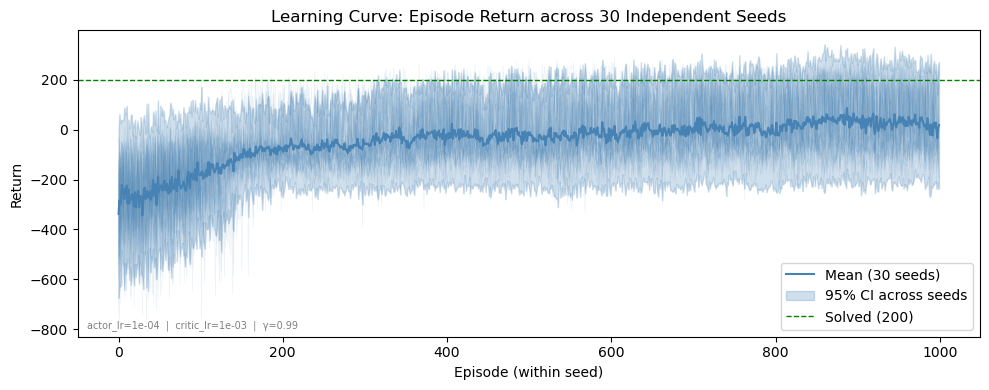

In [13]:
# ── Plot 1: Learning curve across seeds ───────────────────────────────────────
ep_returns = (
    df.groupby(["label", "episode"])["episode_return"]
    .first()
    .unstack(level=0)
)
n_seeds  = ep_returns.shape[1]
mean_ret = ep_returns.mean(axis=1)
std_ret  = ep_returns.std(axis=1)
episodes = ep_returns.index

fig, ax = plt.subplots(figsize=(10, 4))
for col in ep_returns.columns:
    ax.plot(episodes, ep_returns[col], alpha=0.1, color="steelblue", linewidth=0.5)
ax.plot(episodes, mean_ret, color="steelblue", linewidth=1.5, label=f"Mean ({n_seeds} seeds)")
ax.fill_between(episodes,
                mean_ret - 1.96 * std_ret,
                mean_ret + 1.96 * std_ret,
                alpha=0.25, color="steelblue", label="95% CI across seeds")
ax.axhline(200, color="green", linestyle="--", linewidth=1, label="Solved (200)")
ax.set_xlabel("Episode (within seed)"); ax.set_ylabel("Return")
ax.set_title(f"Learning Curve: Episode Return across {n_seeds} Independent Seeds")
ax.legend(loc="lower right")
ax.text(0.01, 0.02, params_str, transform=ax.transAxes, ha="left", va="bottom", fontsize=7, color="gray")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/return_per_episode.png", dpi=150, bbox_inches="tight")
plt.show()

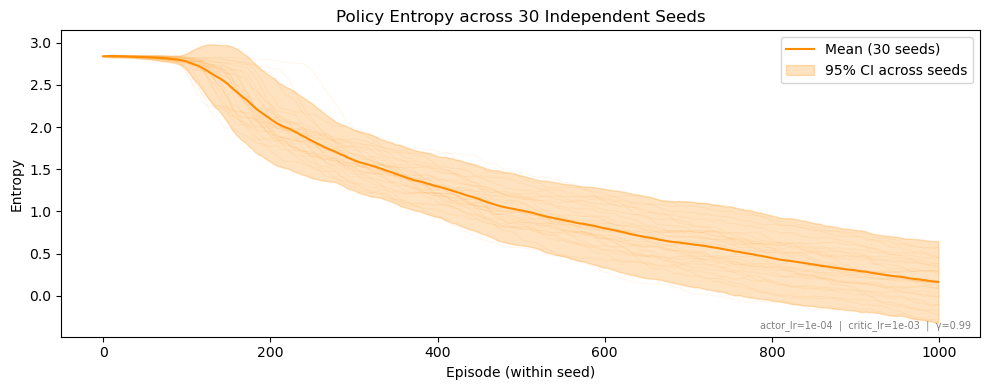

In [14]:
# ── Plot 2: Policy entropy across seeds ───────────────────────────────────────
ep_entropy = (
    df.groupby(["label", "episode"])["entropy"]
    .mean()
    .unstack(level=0)
)
n_seeds  = ep_entropy.shape[1]
mean_ent = ep_entropy.mean(axis=1)
std_ent  = ep_entropy.std(axis=1)
episodes = ep_entropy.index

fig, ax = plt.subplots(figsize=(10, 4))
for col in ep_entropy.columns:
    ax.plot(episodes, ep_entropy[col], alpha=0.1, color="darkorange", linewidth=0.5)
ax.plot(episodes, mean_ent, color="darkorange", linewidth=1.5, label=f"Mean ({n_seeds} seeds)")
ax.fill_between(episodes,
                mean_ent - 1.96 * std_ent,
                mean_ent + 1.96 * std_ent,
                alpha=0.25, color="darkorange", label="95% CI across seeds")
ax.set_xlabel("Episode (within seed)"); ax.set_ylabel("Entropy")
ax.set_title(f"Policy Entropy across {n_seeds} Independent Seeds")
ax.legend()
ax.text(0.99, 0.02, params_str, transform=ax.transAxes, ha="right", va="bottom", fontsize=7, color="gray")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/policy_entropy.png", dpi=150, bbox_inches="tight")
plt.show()

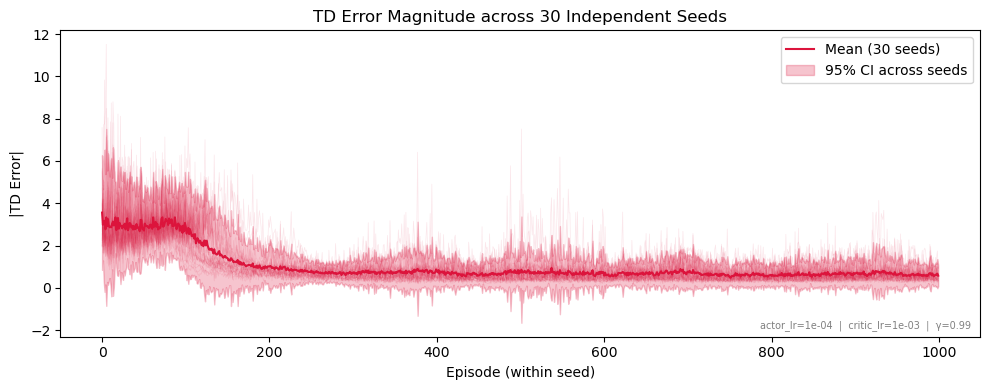

In [15]:
# ── Plot 3: TD error magnitude across seeds ────────────────────────────────────
ep_td = (
    df.groupby(["label", "episode"])["td_error"]
    .apply(lambda x: x.abs().mean())
    .unstack(level=0)
)
n_seeds = ep_td.shape[1]
mean_td = ep_td.mean(axis=1)
std_td  = ep_td.std(axis=1)
episodes = ep_td.index

fig, ax = plt.subplots(figsize=(10, 4))
for col in ep_td.columns:
    ax.plot(episodes, ep_td[col], alpha=0.1, color="crimson", linewidth=0.5)
ax.plot(episodes, mean_td, color="crimson", linewidth=1.5, label=f"Mean ({n_seeds} seeds)")
ax.fill_between(episodes,
                mean_td - 1.96 * std_td,
                mean_td + 1.96 * std_td,
                alpha=0.25, color="crimson", label="95% CI across seeds")
ax.set_xlabel("Episode (within seed)"); ax.set_ylabel("|TD Error|")
ax.set_title(f"TD Error Magnitude across {n_seeds} Independent Seeds")
ax.legend()
ax.text(0.99, 0.02, params_str, transform=ax.transAxes, ha="right", va="bottom", fontsize=7, color="gray")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/td_error.png", dpi=150, bbox_inches="tight")
plt.show()

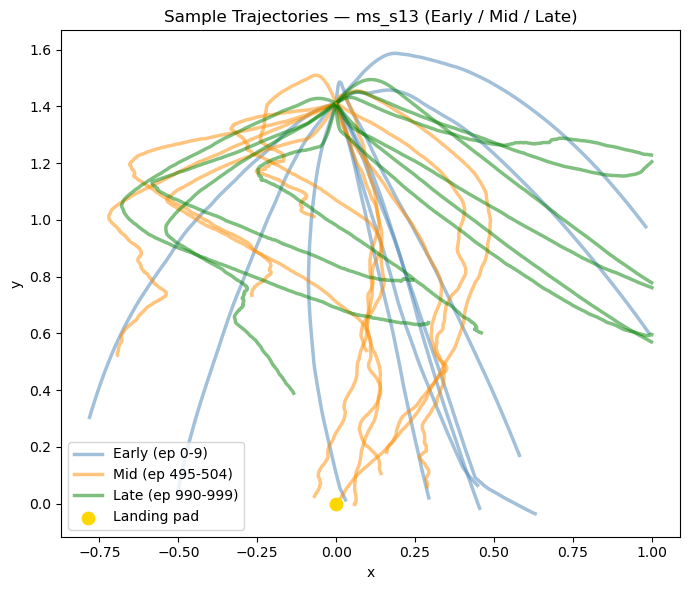

In [16]:
# ── Plot 4: Sample trajectories (single-seed progression) ─────────────────────
_median_label = ranked.index[len(ranked) // 2]
_mid_ep_start = CFG["episodes_per_seed"] // 2 - 5

fig, ax = plt.subplots(figsize=(7, 6))
phases = {
    f"Early (ep 0-9)":                                         (range(0, 10),         "steelblue"),
    f"Mid (ep {_mid_ep_start}-{_mid_ep_start + 9})":          (range(_mid_ep_start,
                                                                       _mid_ep_start + 10), "darkorange"),
    f"Late (ep {CFG['episodes_per_seed']-10}-{CFG['episodes_per_seed']-1})":
                                                               (range(CFG["episodes_per_seed"] - 10,
                                                                      CFG["episodes_per_seed"]), "green"),
}
seed_df = df[df["label"] == _median_label]
for label, (ep_range, color) in phases.items():
    first = True
    for ep in ep_range:
        ep_data = seed_df[seed_df["episode"] == ep]
        ax.plot(ep_data["x"], ep_data["y"], color=color, alpha=0.5, linewidth=2.5,
                label=label if first else None)
        first = False

ax.scatter([0], [0], color="gold", s=80, zorder=5, label="Landing pad")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(f"Sample Trajectories — {_median_label} (Early / Mid / Late)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/trajectories.png", dpi=150)
plt.show()

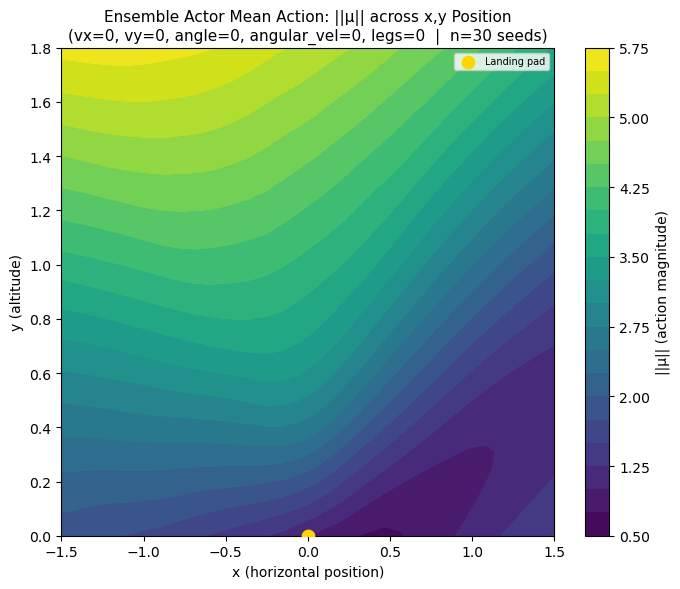

In [17]:
# ── Plot 5: Actor mean action across the state space (ensemble of all seeds) ──
from src.ensemble import ensemble_mu

grid_n = 30
xs = np.linspace(-1.5, 1.5, grid_n)
ys = np.linspace(0.0,  1.8, grid_n)
X, Y = np.meshgrid(xs, ys)

all_actors = []
for label in CFG["seed_labels"]:
    a = Agent.load(f"../data/{label}_final.pt")
    a.actor.eval()
    all_actors.append(a.actor)

magnitude = np.zeros_like(X)
for i, y_val in enumerate(ys):
    for j, x_val in enumerate(xs):
        obs = torch.tensor([x_val, y_val, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], dtype=torch.float32)
        mu = ensemble_mu(all_actors, obs)
        magnitude[i, j] = np.sqrt(mu[0].item()**2 + mu[1].item()**2)

fig, ax = plt.subplots(figsize=(7, 6))
hm = ax.contourf(X, Y, magnitude, levels=20, cmap="viridis")
ax.scatter([0], [0], color="gold", s=80, zorder=5, label="Landing pad")
ax.set_xlabel("x (horizontal position)")
ax.set_ylabel("y (altitude)")
ax.set_title(
    f"Ensemble Actor Mean Action: ||μ|| across x,y Position\n"
    f"(vx=0, vy=0, angle=0, angular_vel=0, legs=0  |  n={len(all_actors)} seeds)",
    fontsize=11,
)
ax.legend(loc="upper right", fontsize=7)
fig.colorbar(hm, ax=ax, label="||μ|| (action magnitude)")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/actor_mean_action.png", dpi=150, bbox_inches="tight")
plt.show()

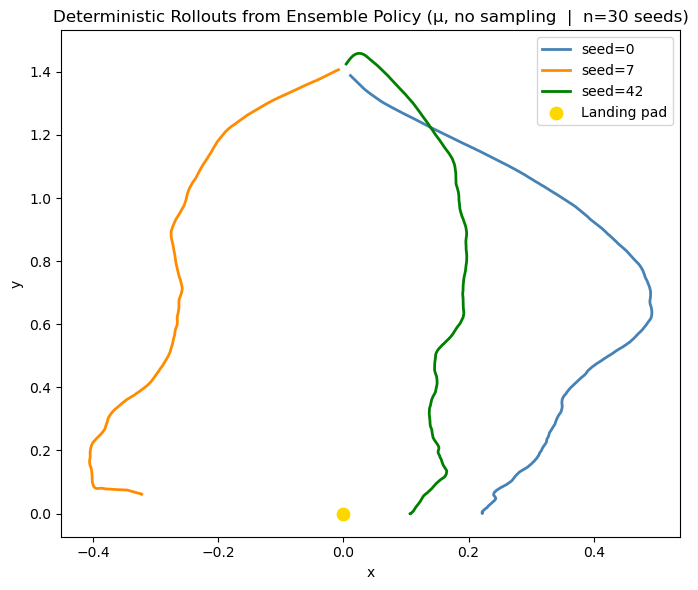

In [18]:
# ── Plot 6: Deterministic rollouts from ensemble policy ────────────────────────
import gymnasium as gym
from src.ensemble import ensemble_mu

EVAL_SEEDS  = [0, 7, 42]
EVAL_COLORS = ["steelblue", "darkorange", "green"]

eval_env = gym.make("LunarLanderContinuous-v3")

fig, ax = plt.subplots(figsize=(7, 6))
for ep_seed, color in zip(EVAL_SEEDS, EVAL_COLORS):
    obs, _ = eval_env.reset(seed=ep_seed)
    xs, ys = [], []
    done = False
    while not done:
        obs_t = torch.FloatTensor(obs)
        mu = ensemble_mu(all_actors, obs_t)
        action = mu.clamp(agent.act_low, agent.act_high).numpy()
        obs, _, terminated, truncated, _ = eval_env.step(action)
        xs.append(float(obs[0]))
        ys.append(float(obs[1]))
        done = terminated or truncated
    ax.plot(xs, ys, color=color, linewidth=2, label=f"seed={ep_seed}")

eval_env.close()
ax.scatter([0], [0], color="gold", s=80, zorder=5, label="Landing pad")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(f"Deterministic Rollouts from Ensemble Policy (μ, no sampling  |  n={len(all_actors)} seeds)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/learned_policy_rollouts.png", dpi=150)
plt.show()

In [19]:
# --- find episodes with closest final landing position to the pad ---
final_steps = df.groupby(["label", "episode"]).last().reset_index()
final_steps["dist_to_pad"] = np.sqrt(final_steps["x"]**2 + final_steps["y"]**2)
closest = final_steps.nsmallest(10, "dist_to_pad")[["label", "episode", "x", "y", "dist_to_pad", "episode_return"]]
print(closest.round(4))

        label  episode       x       y  dist_to_pad  episode_return
16364  ms_s23      364 -0.0003 -0.0001       0.0003         51.4680
19468  ms_s26      468 -0.0005  0.0001       0.0005        258.0590
1719    ms_s1      719 -0.0006 -0.0003       0.0007         83.4986
3659   ms_s11      659  0.0005 -0.0004       0.0007        269.1448
22651  ms_s29      651  0.0003 -0.0006       0.0007         60.8700
15417  ms_s22      417 -0.0008 -0.0002       0.0008        125.0169
17853  ms_s24      853 -0.0005 -0.0007       0.0009        169.6860
12777   ms_s2      777  0.0006 -0.0007       0.0009        255.1767
3984   ms_s11      984 -0.0005 -0.0008       0.0009        274.5882
14620  ms_s21      620  0.0007 -0.0007       0.0010        143.1957


In [20]:
import matplotlib.animation as animation

sample = closest.sample(5, random_state=42)[["label", "episode", "episode_return"]].reset_index(drop=True)

def lander_verts(x, y, angle, scale=0.06):
    body = np.array([[-0.5, -0.5], [0.5, -0.5], [0.5, 0.5], [-0.5, 0.5], [-0.5, -0.5]]) * scale
    c, s = np.cos(angle), np.sin(angle)
    R = np.array([[c, -s], [s, c]])
    return (R @ body.T).T + np.array([x, y])

for i, row in sample.iterrows():
    ep_df = df[(df["label"] == row["label"]) & (df["episode"] == row["episode"])].reset_index(drop=True)
    ep_df = ep_df.copy()
    ep_df["cumulative_return"] = ep_df["reward"].cumsum()
    ep_return = ep_df["episode_return"].iloc[0]
    print(f"Animating {row['label']} ep {row['episode']}  (return={ep_return:.1f},  {len(ep_df)} steps)")

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-0.5, 2.0)
    ax.set_aspect("equal")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title(f"Episode Replay — {row['label']} ep {row['episode']}  (return={ep_return:.1f})")
    ax.scatter([0], [0], color="gold", s=80, zorder=5, label="Landing pad")
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.legend(loc="upper right")

    trail_line,  = ax.plot([], [], color="steelblue", alpha=0.4, linewidth=1)
    lander_body, = ax.plot([], [], color="steelblue", linewidth=2)
    step_text = ax.text(0.02, 0.97, "", transform=ax.transAxes, va="top", fontsize=8)

    def init():
        trail_line.set_data([], [])
        lander_body.set_data([], [])
        step_text.set_text("")
        return trail_line, lander_body, step_text

    def update(f, ep_df=ep_df):
        r = ep_df.iloc[f]
        trail_line.set_data(ep_df["x"][:f+1], ep_df["y"][:f+1])
        verts = lander_verts(r["x"], r["y"], r["angle"])
        lander_body.set_data(verts[:, 0], verts[:, 1])
        step_text.set_text(f"step {f}  cumulative return={r['cumulative_return']:.1f}")
        return trail_line, lander_body, step_text

    ani = animation.FuncAnimation(fig, update, frames=len(ep_df),
                                   init_func=init, interval=30, blit=True)
    path = f"{IMG_DIR}/episode_replay_{i+1}.gif"
    ani.save(path, writer="pillow", fps=30)
    plt.close()
    print(f"  saved to {path}")

Animating ms_s11 ep 984  (return=274.6,  549 steps)
  saved to ../img/episode_replay_1.gif
Animating ms_s26 ep 468  (return=258.1,  832 steps)
  saved to ../img/episode_replay_2.gif
Animating ms_s22 ep 417  (return=125.0,  1000 steps)
  saved to ../img/episode_replay_3.gif
Animating ms_s23 ep 364  (return=51.5,  1000 steps)
  saved to ../img/episode_replay_4.gif
Animating ms_s2 ep 777  (return=255.2,  954 steps)
  saved to ../img/episode_replay_5.gif


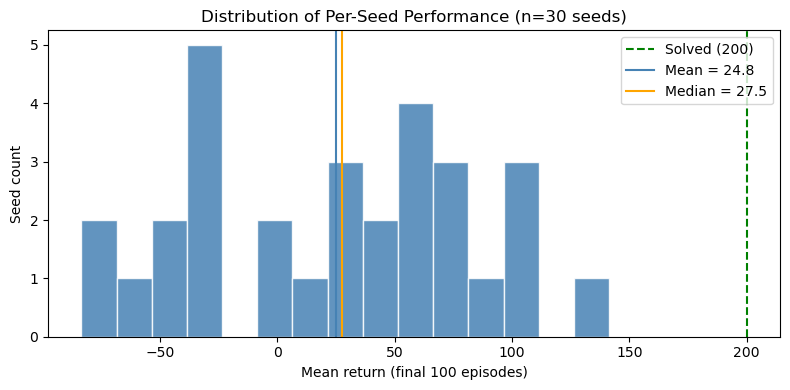

Seeds above 200  : 0
Seeds above 100  : 3
Seeds below 0    : 10

count     30.0
mean      24.8
std       59.8
min      -83.5
25%      -28.7
50%       27.5
75%       69.7
max      141.3
Name: episode_return, dtype: float64


In [21]:
# ── Diagnostic: Distribution of per-seed mean return (final 100 episodes) ─────
import numpy as np
import matplotlib.pyplot as plt

final_100 = (
    df.groupby(["label", "episode"])["episode_return"]
    .first()
    .groupby("label")
    .apply(lambda s: s.iloc[-100:].mean())
    .reindex(CFG["seed_labels"])
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(final_100, bins=15, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(200, color="green", linestyle="--", linewidth=1.5, label="Solved (200)")
ax.axvline(final_100.mean(), color="steelblue", linestyle="-", linewidth=1.5,
           label=f"Mean = {final_100.mean():.1f}")
ax.axvline(final_100.median(), color="orange", linestyle="-", linewidth=1.5,
           label=f"Median = {final_100.median():.1f}")
ax.set_xlabel("Mean return (final 100 episodes)")
ax.set_ylabel("Seed count")
ax.set_title(f"Distribution of Per-Seed Performance (n={len(final_100)} seeds)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/seed_performance_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Seeds above 200  : {(final_100 >= 200).sum()}")
print(f"Seeds above 100  : {(final_100 >= 100).sum()}")
print(f"Seeds below 0    : {(final_100 < 0).sum()}")
print(f"\n{final_100.describe().round(1)}")

Best seed: ms_s11  (mean return over final 100 episodes: 141.3)


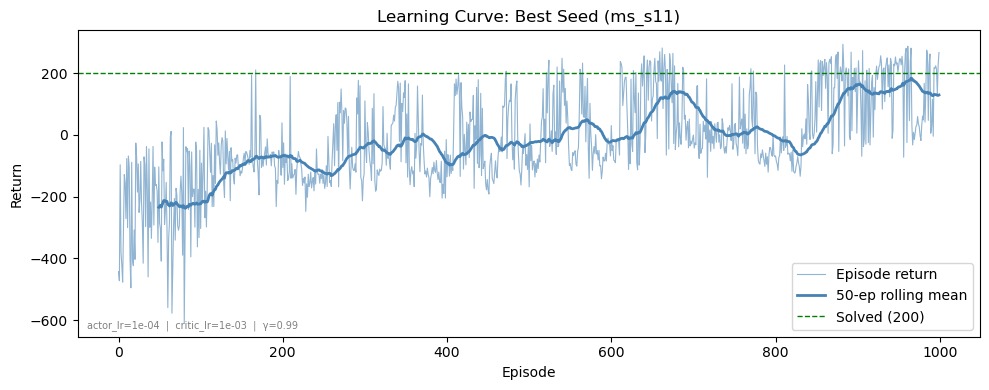

In [22]:
# ── Best seed: episode return curve ───────────────────────────────────────────
best_label = final_100.idxmax()
print(f"Best seed: {best_label}  (mean return over final 100 episodes: {final_100[best_label]:.1f})")

best_df = (
    df[df["label"] == best_label]
    .groupby("episode")["episode_return"]
    .first()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(best_df.index, best_df.values, color="steelblue", linewidth=0.8, alpha=0.6, label="Episode return")
ax.plot(best_df.index, best_df.rolling(50).mean(), color="steelblue", linewidth=2, label="50-ep rolling mean")
ax.axhline(200, color="green", linestyle="--", linewidth=1, label="Solved (200)")
ax.set_xlabel("Episode")
ax.set_ylabel("Return")
ax.set_title(f"Learning Curve: Best Seed ({best_label})")
ax.legend(loc="lower right")
ax.text(0.01, 0.02, params_str, transform=ax.transAxes, ha="left", va="bottom", fontsize=7, color="gray")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/best_seed_return.png", dpi=150, bbox_inches="tight")
plt.show()

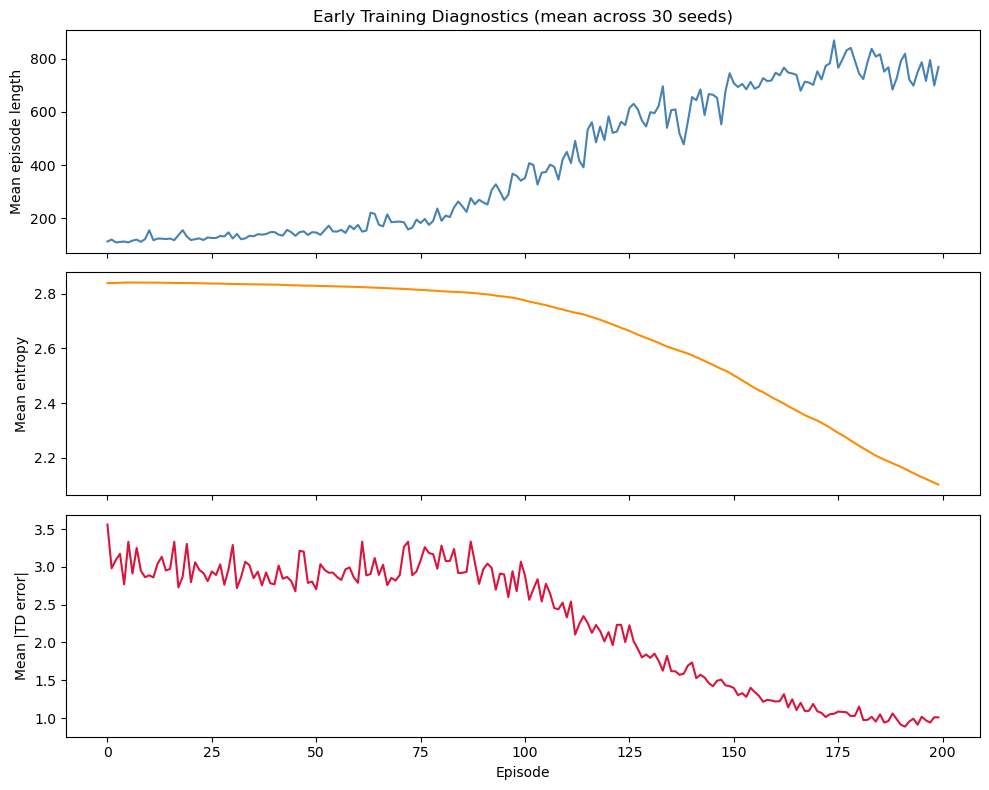

Mean episode length, episodes 0-49  : 130.1
Mean episode length, episodes 50-99 : 214.0
Mean episode length, episodes 100-149: 532.4
Mean episode length, episodes 150-199: 748.4


In [23]:
# ── Diagnostic: Early episode length vs entropy ────────────────────────────────
EARLY = 200

early = (
    df.groupby(["label", "episode"])
    .agg(
        ep_length=("step", "count"),
        mean_entropy=("entropy", "mean"),
        mean_td=("td_error", lambda x: x.abs().mean()),
    )
    .reset_index()
)

early_agg = (
    early[early["episode"] < EARLY]
    .groupby("episode")[["ep_length", "mean_entropy", "mean_td"]]
    .mean()
)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(early_agg.index, early_agg["ep_length"], color="steelblue")
axes[0].set_ylabel("Mean episode length")
axes[0].set_title("Early Training Diagnostics (mean across 30 seeds)")

axes[1].plot(early_agg.index, early_agg["mean_entropy"], color="darkorange")
axes[1].set_ylabel("Mean entropy")

axes[2].plot(early_agg.index, early_agg["mean_td"], color="crimson")
axes[2].set_ylabel("Mean |TD error|")
axes[2].set_xlabel("Episode")

plt.tight_layout()
plt.savefig(f"{IMG_DIR}/early_training_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean episode length, episodes 0-49  : {early_agg['ep_length'][:50].mean():.1f}")
print(f"Mean episode length, episodes 50-99 : {early_agg['ep_length'][50:100].mean():.1f}")
print(f"Mean episode length, episodes 100-149: {early_agg['ep_length'][100:150].mean():.1f}")
print(f"Mean episode length, episodes 150-199: {early_agg['ep_length'][150:200].mean():.1f}")